# H10 -- Risk scoring: a division-level, short-horizon dengue outlook, back-tested

## What PLAN.md asked for, and what could actually be built

H10 asks for a **ward-level risk score, validated against a held-out season**, with
uncertainty, SHAP interpretation, and a "how to read this / what it is not" page.
Two parts of that are impossible with public data (established in H9, not assumed):

1. **Ward-level counts do not exist.** The finest public dengue geography is the 8
   divisions.
2. **A held-out season does not exist.** The only public sub-national series is
   *this year's* division-by-week counts (W01-W37 of 2026). Earlier years are
   national-only (annual, monthly, weekly national totals).

So this notebook builds the version the data can support, and says so up front:

- **Unit: 8 divisions x 37 weeks of 2026** (296 division-weeks, real DGHS data).
- **Output: a short-horizon *outlook*** -- predicted admissions per 100,000 two weeks
  ahead for each division, with an 80% interval, and a ranked list.
- **Validation: rolling-origin backtest inside 2026** (train only on what was already
  resolved at each origin week, predict forward, repeat). This is *time-ordered
  out-of-sample* validation, **not** a held-out-season test, and it is one epidemic
  season, in progress.
- **Two questions asked honestly**: does any model beat trivial baselines, and do
  weather and satellite-derived predictors add anything beyond just extrapolating
  recent cases?

**Predictors.** Autoregressive (recent incidence and its change), weekly weather
(NASA POWER rainfall / temperature / humidity at each division's population-weighted
centroid, lagged), and the H9 static division layers (log population density, JRC
surface-water occurrence). H4/H8's AOI-scale U-Net outputs cover 3 districts of one
division and cannot feed a national division panel -- not used.

**Design fixed before the first real run**: the target (log growth of incidence), the
rolling-origin scheme (first origin week 20), the three feature sets, and all model
hyperparameters (never tuned against the backtest). **Added after the first run, and
disclosed**: a trend-extrapolation baseline (added because persistence predicts zero
growth by construction, which looked like a weak yardstick in a growing epidemic --
that turned out to be wrong: trend extrapolation is *worse* than persistence, see the
results) and the ridge+XGBoost mean ensemble PLAN.md calls for. Every configuration
that was run is reported below.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterstats
import shap

from src.forecast import (
    FEATURE_SETS, ZeroGrowth, add_conformal_intervals, backtest, build_panel, mean_weekly_spearman,
    model_factories, paired_block_bootstrap_rmse_diff, rmse_log, top_k_hit_rate,
)
from src.weather import to_iso_weeks

ROOT = Path('..')
SNAP = ROOT / 'data/snapshots'

## 1. Assemble the real panel

- **Cases**: DGHS division-by-week admissions, snapshot 2026-09-20
  (`scripts/fetch_dengue_dghs.py`). Reconciles to the year-to-date division totals
  (60,370 vs. 60,379; the 9-case gap is the stray DSCC/DNCC/"Raishahi" entries H9 found).
- **Population / static layers**: the same WorldPop-2020 and JRC-water division
  summaries as H9.
- **Weather**: NASA POWER daily rain/temperature/humidity at each division's
  *population-weighted* centroid (`scripts/fetch_weather_power.py`), aggregated to
  complete ISO weeks and indexed so that ISO week 1 of 2026 = DGHS `W01`.
  **Assumption**: DGHS does not document its week boundaries and I could not
  reproduce its weekly totals from its own daily series (checked; the two differ in
  definition), so ISO weeks are an assumption. Weather is used as 4-week windows,
  which a shift of a few days barely changes.

In [2]:
cases = pd.read_csv(SNAP / 'dghs_dengue_weekly_division_2026-09-20.csv', index_col='week')
divisions = list(cases.columns)
LAST_WEEK = int(cases.index.max())

adm1 = gpd.read_file(ROOT / 'data/raw/bgd_adm1.geojson')[['shapeName', 'geometry']].set_index('shapeName').loc[divisions]
adm1.index.name = 'shapeName'
adm1 = adm1.reset_index()
population = pd.Series(
    [z['sum'] for z in rasterstats.zonal_stats(adm1, str(ROOT / 'data/raw/bgd_worldpop_2020_constrained.tif'), stats=['sum'])],
    index=adm1['shapeName'])
water = pd.Series(
    [z['mean'] for z in rasterstats.zonal_stats(adm1, str(ROOT / 'data/raw/bgd_jrc_water_occurrence.tif'), stats=['mean'], nodata=255)],
    index=adm1['shapeName'])
area_km2 = adm1.to_crs(32646).area.values / 1e6
static = pd.DataFrame({'log_density': np.log(population.values / area_km2), 'water_occ': water.values}, index=adm1['shapeName'])

daily = pd.read_csv(SNAP / 'power_daily_divisions_2026-09-20.csv', parse_dates=['date'])
weather = {}
for var in ['rain_mm', 'temp_c', 'rh_pct']:
    per_division = {}
    for division, g in daily.groupby('division'):
        weekly = to_iso_weeks(g.set_index('date')[['rain_mm', 'temp_c', 'rh_pct']])[var]
        # ISO 2025 has 52 weeks: weeks of 2025 become 2025-week - 52 (i.e. <= 0), so W01 of 2026 is week 1
        per_division[division] = pd.Series(weekly.values, index=[w if y == 2026 else w - 52 for (y, w) in weekly.index])
    weather[var] = pd.DataFrame(per_division).sort_index()

print(f'cases: {cases.shape[0]} weeks x {cases.shape[1]} divisions, total {cases.values.sum():,}; last week = W{LAST_WEEK:02d}')
print(f"weather: weeks {weather['rain_mm'].index.min()}..{weather['rain_mm'].index.max()} (week <= 0 = late 2025); "
      f"last week with complete rain data: {int(weather['rain_mm'].dropna().index.max())}")
assert set(weather['rain_mm'].columns) == set(divisions)
assert weather['rain_mm'].loc[-9:LAST_WEEK].notna().all().all(), 'weather gap inside the modelling window'

cases: 37 weeks x 8 divisions, total 60,370; last week = W37
weather: weeks -11..38 (week <= 0 = late 2025); last week with complete rain data: 37


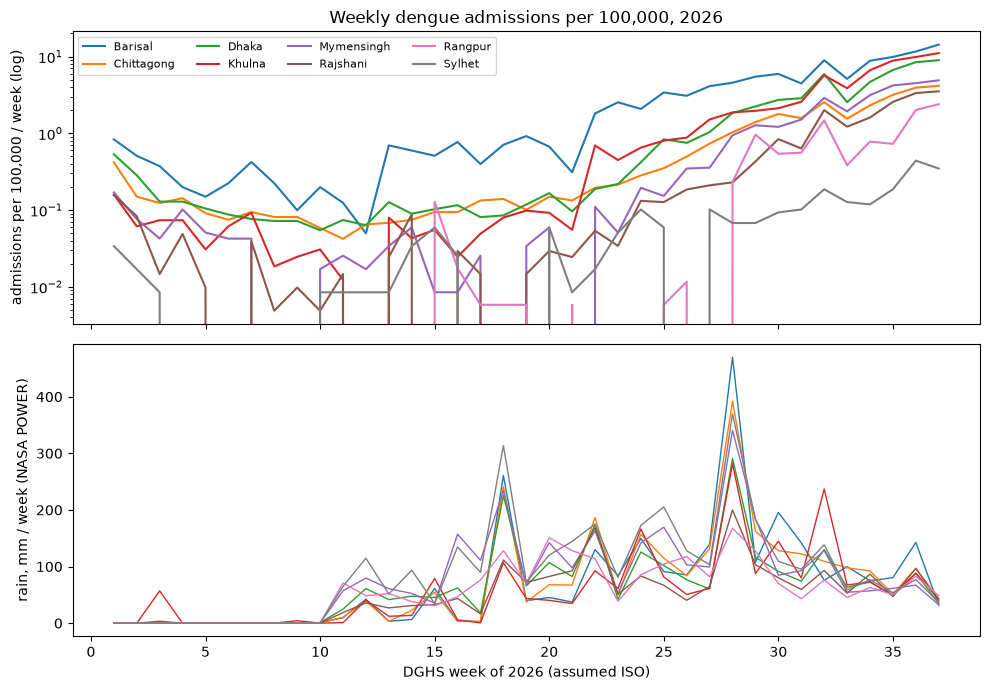

In [3]:
inc = cases.div(population, axis='columns') * 1e5
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for d in divisions:
    axes[0].plot(inc.index, inc[d], label=d, lw=1.5)
axes[0].set_yscale('log'); axes[0].set_ylabel('admissions per 100,000 / week (log)')
axes[0].set_title('Weekly dengue admissions per 100,000, 2026'); axes[0].legend(ncol=4, fontsize=8)
rain = weather['rain_mm'].loc[1:LAST_WEEK]
for d in divisions:
    axes[1].plot(rain.index, rain[d], lw=1)
axes[1].set_ylabel('rain, mm / week (NASA POWER)'); axes[1].set_xlabel('DGHS week of 2026 (assumed ISO)')
plt.tight_layout(); plt.show()

## 2. Rolling-origin backtest

**Target.** `growth = log1p(incidence at t+h) - log1p(incidence at t)`. Predicting
growth (rather than the level) makes *persistence* literally "predict growth = 0", so
"beats persistence" means "predicted growth is better than zero" -- and lets tree
models cope with an epidemic growing out of their training range.

**No leakage.** At origin week `o`, a fresh model is trained only on rows whose
*target* week is <= `o` (so everything it learns from had already happened), then
predicts `o + h` for all 8 divisions. First origin = week 20; horizons h = 1, 2, 4
weeks; all three horizons are reported (no picking the best).

**Baselines.** *Persistence* (no change) and *trend* (last two weeks' average log
change continues; added after the first run, see above). **Models.** Ridge, a depth-2 XGBoost, and their mean ensemble, each
on three feature sets: `autoregressive` (own incidence + its recent change),
`plus_weather` (adds lagged rain/temperature/humidity), `plus_static` (adds density and
water occupancy).

**Metrics.** `rmse_log` -- error of log1p(incidence), a multiplicative error (0.25 is
roughly "25% off"); mean per-week Spearman rank correlation and top-2 hit rate -- the
metrics for a *ranked* list.

In [4]:
HORIZONS = (1, 2, 4)
FIRST_ORIGIN = 20
panels = {h: build_panel(cases, population, weather, static, h) for h in HORIZONS}

runs = {}
for h in HORIZONS:
    origins = range(FIRST_ORIGIN, LAST_WEEK - h + 1)
    runs[(h, '-', 'persistence')] = backtest(panels[h], ZeroGrowth, FEATURE_SETS['autoregressive'], origins, h)
    for feature_set, features in FEATURE_SETS.items():
        for name, factory in model_factories(h, features).items():
            if name == 'trend' and feature_set != 'autoregressive':
                continue  # trend uses only d1/d2, so it is identical in every feature set
            key = (h, '-' if name == 'trend' else feature_set, name)
            runs[key] = backtest(panels[h], factory, features, origins, h)

rows = []
for (h, feature_set, name), pred in runs.items():
    rows.append({'horizon (wk)': h, 'model': name, 'features': feature_set, 'points': len(pred),
                 'RMSE (log)': rmse_log(pred), 'Spearman': mean_weekly_spearman(pred), 'top-2 hit': top_k_hit_rate(pred, 2)})
results = pd.DataFrame(rows)
persistence_rmse = results[results['model'] == 'persistence'].set_index('horizon (wk)')['RMSE (log)']
trend_rmse = results[results['model'] == 'trend'].set_index('horizon (wk)')['RMSE (log)']
results['vs persistence'] = results['RMSE (log)'] / results['horizon (wk)'].map(persistence_rmse) - 1
results['vs trend'] = results['RMSE (log)'] / results['horizon (wk)'].map(trend_rmse) - 1
order = {'persistence': 0, 'trend': 1, 'ridge': 2, 'xgboost': 3, 'ensemble': 4}
results = results.sort_values(['horizon (wk)', 'model', 'features'], key=lambda s: s.map(order) if s.name == 'model' else s)
fmt = results.copy()
for c in ['RMSE (log)', 'Spearman', 'top-2 hit']:
    fmt[c] = fmt[c].round(3)
for c in ['vs persistence', 'vs trend']:
    fmt[c] = (fmt[c] * 100).round(0).astype(int).astype(str) + '%'
print(fmt.to_string(index=False))

 horizon (wk)       model       features  points  RMSE (log)  Spearman  top-2 hit vs persistence vs trend
            1 persistence              -     136       0.239     0.957      0.824             0%     -14%
            1       trend              -     136       0.278     0.945      0.853            16%       0%
            1       ridge autoregressive     136       0.224     0.959      0.853            -6%     -19%
            1       ridge    plus_static     136       0.225     0.947      0.882            -6%     -19%
            1       ridge   plus_weather     136       0.224     0.945      0.882            -6%     -19%
            1     xgboost autoregressive     136       0.244     0.959      0.853             2%     -12%
            1     xgboost    plus_static     136       0.249     0.959      0.824             4%     -10%
            1     xgboost   plus_weather     136       0.250     0.955      0.824             5%     -10%
            1    ensemble autoregressive     1

## 3. Do weather and satellite-derived layers add anything?

Point differences between rows of the table above are small enough that they need an
uncertainty range. For each comparison, RMSE(a) - RMSE(b) with a 95% **moving-block
bootstrap over origin weeks** (blocks of 4 weeks keep neighbouring, autocorrelated
weeks together; resampling individual rows would give falsely narrow intervals).
**Negative = the first is better.** Ensemble models are used to keep the number of
comparisons down; 15 unadjusted intervals is still a multiple-comparisons situation,
so read them as descriptive.

In [5]:
def compare(h, a, b):
    diff, lo, hi = paired_block_bootstrap_rmse_diff(runs[a], runs[b])
    return {'horizon (wk)': h, 'RMSE(a) - RMSE(b)': round(diff, 3), '95% CI': f'{lo:+.3f} to {hi:+.3f}',
            'a better?': 'yes' if hi < 0 else ('no (worse)' if lo > 0 else 'unclear')}

comparisons = {
    'ensemble AR-only  vs  persistence  (do models beat "no change"?)': lambda h: ((h, 'autoregressive', 'ensemble'), (h, '-', 'persistence')),
    'ensemble+weather  vs  persistence': lambda h: ((h, 'plus_weather', 'ensemble'), (h, '-', 'persistence')),
    'ensemble+weather  vs  ensemble AR-only  (does weather help?)': lambda h: ((h, 'plus_weather', 'ensemble'), (h, 'autoregressive', 'ensemble')),
    'ensemble+static  vs  ensemble+weather  (do density/water help?)': lambda h: ((h, 'plus_static', 'ensemble'), (h, 'plus_weather', 'ensemble')),
    'trend baseline  vs  persistence  (is extrapolating the recent trend better?)': lambda h: ((h, '-', 'trend'), (h, '-', 'persistence')),
}
for title, keys in comparisons.items():
    print('--', title)
    print(pd.DataFrame([compare(h, *keys(h)) for h in HORIZONS]).to_string(index=False))

-- ensemble AR-only  vs  persistence  (do models beat "no change"?)
 horizon (wk)  RMSE(a) - RMSE(b)           95% CI a better?
            1             -0.009 -0.030 to +0.006   unclear
            2             -0.058 -0.098 to -0.012       yes
            4             -0.147 -0.209 to -0.058       yes
-- ensemble+weather  vs  persistence
 horizon (wk)  RMSE(a) - RMSE(b)           95% CI a better?
            1             -0.007 -0.033 to +0.012   unclear
            2             -0.071 -0.104 to -0.027       yes
            4             -0.193 -0.250 to -0.106       yes
-- ensemble+weather  vs  ensemble AR-only  (does weather help?)


 horizon (wk)  RMSE(a) - RMSE(b)           95% CI a better?
            1              0.002 -0.018 to +0.017   unclear
            2             -0.013 -0.034 to +0.004   unclear
            4             -0.046 -0.088 to -0.013       yes


-- ensemble+static  vs  ensemble+weather  (do density/water help?)
 horizon (wk)  RMSE(a) - RMSE(b)           95% CI  a better?
            1              0.000 -0.000 to +0.001    unclear
            2              0.002 +0.000 to +0.003 no (worse)
            4              0.011 +0.003 to +0.023 no (worse)
-- trend baseline  vs  persistence  (is extrapolating the recent trend better?)
 horizon (wk)  RMSE(a) - RMSE(b)           95% CI a better?
            1              0.039 -0.000 to +0.073   unclear
            2              0.044 -0.029 to +0.098   unclear
            4              0.026 -0.122 to +0.129   unclear


**How to read the weather comparison.** This is a single season. Weather in 2026 is
strongly time-structured (monsoon onset), and so is the epidemic. A model can use
"rainfall in the last 4 weeks" as a stand-in for "where we are in the season", and
one season cannot separate that from a genuine rainfall effect. An apparent benefit
from weather here is therefore *weak* evidence of a causal or transferable
relationship -- it would need several seasons to test properly.

## 4. Are the intervals honest? (primary configuration)

The **primary configuration** is the two-week horizon, ridge + XGBoost mean ensemble on
`plus_weather` (chosen for lead time, the plan's ensemble, and because the
feature-set comparison does not support the static layers). Intervals come from the
model's own past out-of-sample errors, using only errors already observable at each
origin (an error at origin `o'` is only known once week `o' + h` has happened);
coverage is then checked on later origins.

In [6]:
H = 2
primary_key = (H, 'plus_weather', 'ensemble')
with_intervals = add_conformal_intervals(runs[primary_key], horizon=H, level=0.8, min_errors=40)
scored = with_intervals.dropna(subset=['covered'])
print(f"origins with an interval: {sorted(scored['origin'].unique())[0]}..{sorted(scored['origin'].unique())[-1]}, points: {len(scored)}")
print(f"nominal 80% interval -> observed coverage {scored['covered'].mean():.0%}  (n = {len(scored)}, but autocorrelated, so effectively fewer independent checks)")
print(f"mean interval half-width on the log1p scale: {((scored['hi'] - scored['lo']) / 2).mean():.2f}  (~ +/-{np.expm1((scored['hi'] - scored['lo']).mean() / 2) * 100:.0f}% multiplicative)")
by_div = scored.groupby('division')['covered'].mean().round(2).to_dict()
print('coverage by division:', by_div)

origins with an interval: 26..35, points: 80
nominal 80% interval -> observed coverage 61%  (n = 80, but autocorrelated, so effectively fewer independent checks)
mean interval half-width on the log1p scale: 0.23  (~ +/-26% multiplicative)
coverage by division: {'Barisal': 0.6, 'Chittagong': 0.7, 'Dhaka': 0.6, 'Khulna': 0.6, 'Mymensingh': 0.9, 'Rajshani': 0.7, 'Rangpur': 0.3, 'Sylhet': 0.5}


## 5. The outlook: ranked division risk, two weeks ahead of the latest data

Final model = the primary configuration trained on every row resolved by the latest
week. The score is **predicted admissions per 100,000 in week `W37 + 2`**, with an 80%
interval from the pooled past out-of-sample errors of this same configuration, and a
0-100 scaling for a normalised score (`100 x predicted incidence / the highest
predicted incidence`). **Where two divisions' intervals overlap, their order is not
distinguishable.**

In [7]:
features = FEATURE_SETS['plus_weather']
panel = panels[H]
train = panel.dropna(subset=['growth'])
assert (train['target_week'] <= LAST_WEEK).all()
final_model = model_factories(H, features)['ensemble']().fit(train[features].to_numpy(), train['growth'].to_numpy())

now = panel[panel['week'] == LAST_WEEK].reset_index(drop=True)
predicted_log = now['log_inc0'].to_numpy() + final_model.predict(now[features].to_numpy())
past_errors = runs[primary_key]['y_true'] - runs[primary_key]['y_pred']
q_lo, q_hi = past_errors.quantile([0.1, 0.9])

outlook = pd.DataFrame({
    'division': now['division'],
    f'latest week W{LAST_WEEK:02d}, per 100k': np.expm1(now['log_inc0']),
    f'forecast W{LAST_WEEK + H:02d}, per 100k': np.expm1(predicted_log),
    '80% low': np.expm1(predicted_log + q_lo),
    '80% high': np.expm1(predicted_log + q_hi),
})
outlook['score (0-100)'] = 100 * outlook[f'forecast W{LAST_WEEK + H:02d}, per 100k'] / outlook[f'forecast W{LAST_WEEK + H:02d}, per 100k'].max()
outlook = outlook.sort_values(f'forecast W{LAST_WEEK + H:02d}, per 100k', ascending=False).reset_index(drop=True)
outlook.index = outlook.index + 1; outlook.index.name = 'rank'
print(f'interval quantiles from {len(past_errors)} past out-of-sample errors: {q_lo:+.2f} / {q_hi:+.2f} (log1p scale)')
print(outlook.round(1).to_string())

interval quantiles from 128 past out-of-sample errors: -0.18 / +0.37 (log1p scale)
        division  latest week W37, per 100k  forecast W39, per 100k  80% low  80% high  score (0-100)
rank                                                                                                 
1        Barisal                       14.3                    19.4     16.1      28.7          100.0
2         Khulna                       11.1                    16.4     13.6      24.3           84.3
3          Dhaka                        9.0                    13.6     11.2      20.2           69.8
4     Mymensingh                        4.9                     6.9      5.7      10.5           35.7
5     Chittagong                        4.2                     6.2      5.1       9.5           32.0
6       Rajshani                        3.5                     5.1      4.1       7.9           26.5
7        Rangpur                        2.4                     3.3      2.6       5.2           16.9

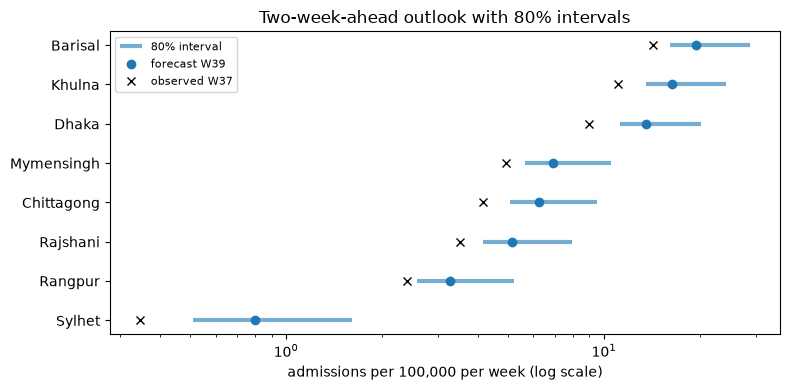

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(outlook))[::-1]
col = f'forecast W{LAST_WEEK + H:02d}, per 100k'
ax.hlines(y, outlook['80% low'], outlook['80% high'], color='tab:blue', lw=3, alpha=0.6, label='80% interval')
ax.plot(outlook[col], y, 'o', color='tab:blue', label=f'forecast W{LAST_WEEK + H:02d}')
ax.plot(outlook[f'latest week W{LAST_WEEK:02d}, per 100k'], y, 'x', color='black', label=f'observed W{LAST_WEEK:02d}')
ax.set_yticks(y); ax.set_yticklabels(outlook['division']); ax.set_xscale('log')
ax.set_xlabel('admissions per 100,000 per week (log scale)'); ax.legend(fontsize=8)
ax.set_title('Two-week-ahead outlook with 80% intervals'); plt.tight_layout(); plt.show()

## 6. Interpretation: what drives the model (SHAP + ridge)

SHAP values for the XGBoost half of the ensemble, and the standardised ridge
coefficients for the linear half, both on the final training set. **These explain what
the fitted models use to predict *growth*, not what causes dengue.** Because of the
single-season confounding discussed in section 3, rainfall/temperature attributions
mostly say "the model found time-of-season information there".

mean |SHAP| (effect on predicted log-growth):
rh_recent       0.0560
d1              0.0403
temp_recent     0.0329
log_inc0        0.0244
d2              0.0198
rain_earlier    0.0115
rain_recent     0.0080


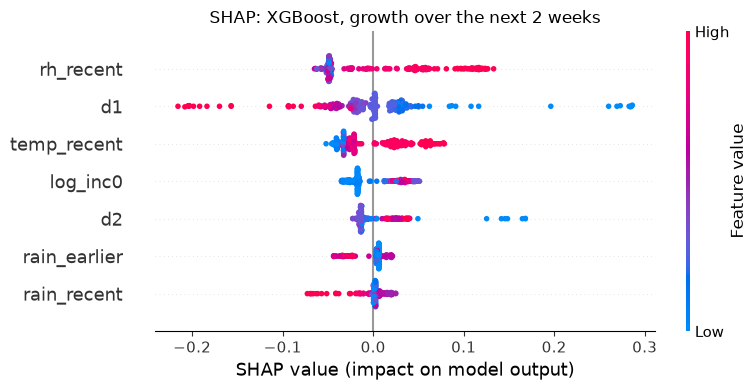


ridge standardised coefficients (per 1 SD of the feature -> change in predicted log-growth):
d1             -0.089
rain_recent    -0.046
d2             -0.015
rain_earlier    0.011
temp_recent     0.058
rh_recent       0.059
log_inc0        0.077


In [9]:
X = train[features]
xgb_only = model_factories(H, features)['xgboost']().fit(X.to_numpy(), train['growth'].to_numpy())
explainer = shap.TreeExplainer(xgb_only)
shap_values = explainer.shap_values(X)
mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=features).sort_values(ascending=False)
print('mean |SHAP| (effect on predicted log-growth):')
print(mean_abs.round(4).to_string())
shap.summary_plot(shap_values, X, show=False, plot_size=(8, 4))
plt.title('SHAP: XGBoost, growth over the next 2 weeks'); plt.tight_layout(); plt.show()

ridge_only = model_factories(H, features)['ridge']().fit(X.to_numpy(), train['growth'].to_numpy())
coef = pd.Series(ridge_only[-1].coef_, index=features).sort_values()
print('\nridge standardised coefficients (per 1 SD of the feature -> change in predicted log-growth):')
print(coef.round(3).to_string())

## 7. Limitations -- what this is not

- **Not a ward-level map, and not a held-out-season test.** 8 divisions; one season in
  progress; validation is time-ordered within 2026. Nothing here shows the approach
  generalises to another year or to finer units.
- **Not a diagnosis of what causes transmission.** Weather and SHAP attributions are
  predictive associations from one season. See the confounding note in section 3.
- **Ecological, aggregate data.** Everything is a division-level average
  (ecological fallacy); it says nothing about any household or ward. One weather point
  per division (population-weighted centroid) is a very coarse summary of areas of
  10,000-30,000 km2 (MAUP).
- **What is being forecast is *reported hospital admissions*, attributed (likely) to
  the reporting hospital's division.** Care-seeking, referral into Dhaka, and reporting
  delays/completeness all sit between "risk" and the number being predicted. A
  forecast of admissions is not a forecast of infections or of where people will be
  bitten. The most recent weeks are also the most likely to be revised.
- **Epidemic-phase dependence.** Every model was trained and tested during a rising
  epidemic (weeks 20-37); the growth relationship near and after a peak is not
  represented in the training data, so behaviour there is unknown and the intervals
  (calibrated on a growing phase) may not hold.
- **Week definition assumed (ISO)**; DGHS's is undocumented.
- **Small-n statistics.** ~130 backtest points per horizon that are strongly
  autocorrelated over time and across divisions -- the effective sample is far smaller
  than the row count, and the bootstrap intervals are still approximate.
- **Not for operational decisions on its own.** A ranked list of 8 divisions that
  mostly reproduces the previous week's ranking is not decision-grade for resource
  allocation without local knowledge; see `docs/HOW_TO_READ.md`.

## 8. What was found

Against the real 2026 division-by-week data, back-tested time-ordered within the season:

- **Models beat "no change" at 2 and 4 weeks, not at 1.** Ensemble (+weather) RMSE on
  log incidence: 0.231 vs. persistence 0.302 at 2 weeks (-24%; RMSE difference
  -0.071, 95% CI -0.104 to -0.027) and 0.296 vs. 0.488 at 4 weeks (-39%; -0.193,
  -0.250 to -0.106). At 1 week the gain is 3% and the interval spans zero (-0.007,
  -0.033 to +0.012) -- at one week, last week's value is about as good as it gets.
- **My added trend baseline was not "fairer" -- it was worse than persistence** at
  every horizon (+14% RMSE at 2 weeks; the interval on the difference includes 0, so
  "not better" is what is established). Weekly changes here are noisy and
  mean-reverting: the ridge coefficient on last week's change is *negative* (-0.089
  per SD), the opposite of trend extrapolation.
- **Weather helps only at 4 weeks, and that is weak evidence.** Adding lagged weather
  to the ensemble: -0.046 (-0.088 to -0.013) at 4 weeks; unclear at 2 weeks (-0.013,
  -0.034 to +0.004); nothing at 1 week. With one season, weather is confounded with
  season/time (section 3), so this does not show that rainfall or humidity drive
  dengue growth. It is also 15 unadjusted comparisons.
- **The static satellite/population layers (density, water occupancy) add nothing**
  -- slightly *worse* at 2 and 4 weeks (+0.002, +0.011; intervals just above 0). Same
  direction as H9's null result on these layers.
- **The ranking is essentially last week's ranking.** Mean per-week Spearman between
  predicted and observed division ranks is 0.92-0.96 for every ridge / XGBoost /
  ensemble variant and 0.957 / 0.951 / 0.939 for plain persistence (at 1 / 2 / 4
  weeks); top-2 hit rate moves within
  noise (persistence 0.82 / 0.75 / 0.68; best ensembles 0.88 / 0.81 / 0.71). What the
  models improve is the *magnitude* (growth) forecast, not which divisions are on top --
  that ordering (Barisal, Khulna, Dhaka highest per person; Sylhet lowest) is stable.
- **The intervals under-cover.** Nominal 80% intervals covered **61%** of held-out
  points (80 points, origins 26-35; Rangpur only 30%). The past errors they are built
  from are asymmetric (-0.18 / +0.37): the model tends to *under*-predict growth in this
  accelerating epidemic. Treat the "80%" columns as roughly 60% intervals that are
  probably too narrow; I did not re-tune them on the same backtest.
- **The outlook** (W37 -> W39): Barisal 19.4 (16.1-28.7) per 100k per week, Khulna 16.4
  (13.6-24.3), Dhaka 13.6 (11.2-20.2), then Mymensingh 6.9, Chittagong 6.2, Rajshani
  5.1, Rangpur 3.3, Sylhet 0.8. The order is identical to the latest observed week,
  and the intervals overlap within {Barisal, Khulna, Dhaka} and within {Mymensingh,
  Chittagong, Rajshani}: honestly, **three tiers, not eight ranks**.
- **SHAP / ridge**: recent relative humidity (mean |SHAP| 0.056), last week's change
  (0.040) and recent temperature (0.033) carry the most weight; rainfall the least
  (0.008-0.012). Consistent with the models using seasonal-phase information (humidity
  and temperature rise with the monsoon) more than a specific rainfall mechanism -- an
  interpretation of the pattern, not something the data can confirm.

**Against the H10 "done when":** a ranked risk list with uncertainty and a one-page
"how to read this / what it is not" now exist ([`docs/HOW_TO_READ.md`](../docs/HOW_TO_READ.md)),
back-tested on one season **in a time-ordered rolling-origin sense, not on a held-out
season**, at division level, not ward level. The list adds little beyond last week's
ranking, the uncertainty is under-stated, and none of this supports operational
allocation decisions on its own. Getting to what PLAN.md describes needs ward- or
upazila-level counts across more than one season -- a data request to DGHS/IEDCR.